# Sandy Beach Invertebrate & Shorebird Analysis
This notebook analyzes the relationship between invertebrate biomass and shorebird abundance across 24 sandy beach sites in Santa Barbara and Ventura Counties (2017–2018).

## Setup

In [31]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Connect to Database

In [32]:
conn = duckdb.connect("database/beach_ecology.db")
cur = conn.cursor()

## Analytical Query
Joining invertebrate biomass and shorebird counts aggregated by site.

In [12]:
# Execute analytical query
cur.execute("""
    SELECT i.site,
        i.total_biomass,
       b.total_birds
    FROM (
    SELECT site, SUM(biomass) AS total_biomass
    FROM invertebrates
    GROUP BY site
) i JOIN (
    SELECT site, SUM(count) AS total_birds
    FROM shorebirds
    GROUP BY site
) b ON i.site = b.site
ORDER BY total_biomass DESC 
            """)
beach_ecology = cur.df()
beach_ecology.head()

,site,total_biomass,total_birds
0,Isla Vista,4169.64,410.0
1,East Campus,1614.09,716.0
2,Solimar,1598.63,168.0
3,Rincon,1594.94,91.0
4,Wallace,1533.71,114.0


## Visualization
Scatter plot of total invertebrate biomass vs. total shorebird count per site.

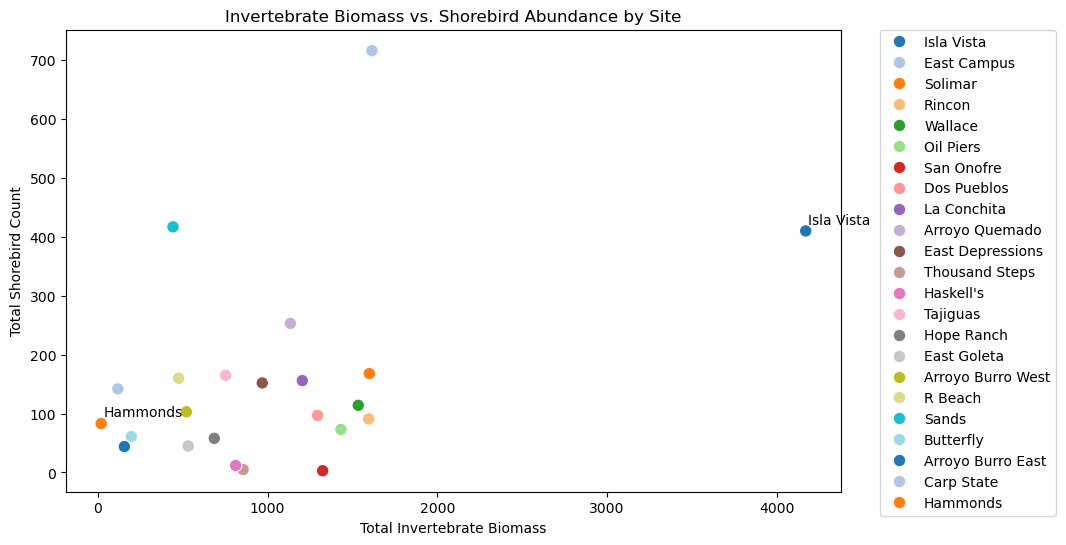

In [30]:
fig, ax = plt.subplots(figsize= (10,6))
sns.scatterplot(data=beach_ecology, x="total_biomass", y="total_birds", hue="site", s=80, palette="tab20", ax=ax)

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
# Label outliers
for _, row in beach_ecology.iterrows():
    if row["site"] in ["Hammonds", "Isla Vista"]:
        ax.annotate(row["site"], (row["total_biomass"], row["total_birds"]),
                    textcoords="offset points", xytext=(2, 5))
        
plt.xlabel("Total Invertebrate Biomass")
plt.ylabel("Total Shorebird Count")
plt.title("Invertebrate Biomass vs. Shorebird Abundance by Site")
plt.show()

## Findings
No clear positive relationship was found between invertebrate biomass and shorebird abundance. 
This suggests that wrack subsidies, the missing variable in this analysis, may play a more direct role in driving shorebird distribution.

### Dont forget

In [33]:
# Close database connection
conn.close()